# Graded Homework 2

## Part I: Modelling Fire dynamics using Transformers

Disclaimer: The whole notebook can easily be executed on colab, even without a GPU. Training all networks should last roughly 45min on Colab (with CPU). It might take only half the time if you do it locally on your machine, Colabs CPU's are not great... if you run in to troubles, you can reduce the run time to 150 epochs instead of 300.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

### Fire Dynamics Simulation

We examine a process that simulates lightning and fire spreading in a growing forest.
We consider a 2D grid on which each cell is in one out of 5 states:

In [2]:
n_classes = 5

EMPTY = 0
TREE  = 1
LIGHTNING = 2
FIRE_LARGE = 3
FIRE_SMALL = 4

They model whether there is a tree, some fire, whether it was struck by lightning or whether it is simply empty.

Given a grid $\mathbf X \in K^{s\times s}$ where $s$ is the grid dimension or side length, and $K = \{EMPTY, TREE, LIGHTNING, FIRE\_LARGE, FIRE\_SMALL\}$ we consider how this process is evolving over time, as you can see in the video `forest_fire.mp4` downloadable from moodle.

In order to visualize a 2D grid in the exact same way you can use the following function:

In [3]:

cmap = ListedColormap([
    "#9e9e9e",   # EMPTY
    "#1fa11f",   # TREE
    "#ff006a",   # LIGHTNING
    "#e58947",   # FIRE_LARGE
    "#db9e62",   # FIRE_SMALL
])


def visualize_grid(grid, ax, title):
    im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=4)
    ax.set_title(title)
    ax.axis('off')
    return im


More precisely, the evolution of the system is driven by a 2-step update process.
First, the fire spreads:
$$
\tilde{X_t} = F(\mathbf X_t)
$$
and then at any given cell some lightning and tree growth are applied
$$
X_{t+1} = G\left(\tilde{X_t}; (M^{\rm growth})_t , (M^{\rm lightning})_t\right)\,,$$
where the matrices $M^{\rm growth} , M^{\rm lightning} \in \{0,1\}^{s \times s}$ and signify whether a tree (or lightning) is growing (stiking) at cell $(ij)$.

At every time step $t$ we sample a new $(M^{\rm growth}_{ij})^t \sim B(p_{\rm growth})$ and $(M^{\rm lightning}_{ij})^t \sim B(p_{\rm lightning})$ where $B$ is a Bernoulli distribution.

Below you see the code we use for generating the process, which implements concrete instances of $F$ (spread_fire) and $G$ (strike_lightning_and_grow_trees) that define how the fire is spread and how the lightning and growth affect a given cell.

In [4]:
def initialize_grid(grid_dim: int, init_tree_density: float, rng = None):
    if rng is None:
        rng = np.random
    grid = (rng.random((grid_dim, grid_dim)) < init_tree_density).astype(int)
    return grid

def step(grid: np.ndarray,
            growth_prob: float,
            lightning_prob: float,
            extra_info: bool = False,
            rng=None):
    if rng is None:
        rng = np.random

    new = spread_fire(grid)
    new, growth, lightning = strike_lightning_and_grow_trees(
        new, growth_prob, lightning_prob, rng
    )

    if extra_info:
        return new.astype(int), growth, lightning
    else:
        return new.astype(int)

def spread_fire(grid: np.ndarray):
    new = grid.copy()

    fire_mask = (grid == LIGHTNING) | (grid == FIRE_LARGE) | (grid == FIRE_SMALL)

    nb = (
        np.roll(fire_mask, 1, axis=0) |
        np.roll(fire_mask, -1, axis=0) |
        np.roll(fire_mask, 1, axis=1) |
        np.roll(fire_mask, -1, axis=1)
    )

    new[(grid == TREE) & nb] = FIRE_LARGE

    new[grid == LIGHTNING] = FIRE_LARGE
    new[grid == FIRE_LARGE] = FIRE_SMALL
    new[grid == FIRE_SMALL] = EMPTY

    return new.astype(int)

def strike_lightning_and_grow_trees(grid: np.ndarray,
                                        growth_prob: float,
                                        lightning_prob: float,
                                        rng=None):
    if rng is None:
        rng = np.random

    new = grid.copy()
    N = grid.shape[0]

    lightning = (rng.random((N, N)) < lightning_prob)
    new[(grid == TREE) & lightning] = LIGHTNING

    growth = (rng.random((N, N)) < growth_prob)
    new[(grid == EMPTY) & growth] = TREE

    return new.astype(int), growth, lightning

*Exercise 1 (3 pts):*

a) Understand the code and write down which exact process is being implemented here.
In particular describe:
- Write down what $F$ and $G$ do in mathematical terms.
- How is the process initialized, what parameter can influence this?

b) For the random seed 34 (rng = np.random.RandomState(seed=34)), evolve the process for 100 steps. Visualize the first and last steps using the `visualize_grid` function above. Compute how many trees are left at the last time step.

---

*Answer 1a:* 

**F: Fire spreading**

The fire spreads deterministically using the von Neumann neighborhood (up, down, left, right). This rule is fully determined by the input with no randomness involved; the same input will always produce the same output.

For each cell (i,j): If the cell is a tree and at least one neighbor is burning ($\rm{FIRE LARGE}$, $\rm{FIRE SMALL}$, or $\rm{LIGHTNING}$), it becomes $\rm{FIRE LARGE}$. The fire progresses through stages:
$$\rm{LIGHTNING} \to \rm{FIRE LARGE} \to \rm{FIRE SMALL} \to \rm{EMPTY}.$$
Mathematically, if we denote the intermediate state as $\tilde{X_t} = F(\mathbf X_t)$, the update depends only on the current state and neighboring cells:

\begin{equation}
    \tilde X_{ij} =
    \begin{cases}
        \rm{FIRE LARGE} & \text{if } X_{ij} = \rm{TREE} \text{and any neighbor is burning},\\
        \rm{FIRE LARGE} & \text{if } X_{ij} = \rm{LIGHTNING} \\
        \rm{FIRE SMALL} & \text{if } X_{ij} = \rm{FIRE LARGE} \\
        \rm{EMPTY} & \text{if } X_{ij} = \text{FIRE SMALL} \\
        X_{ij} & \text{otherwise}.
    \end{cases}
\end{equation}

a neighbor is burning if his classe is in $\{ \rm{LIGHTNING}, \rm{FIRE LARGE}, \rm{FIRE SMALL} \}$.

**G: Lightning and growth**

This rule is stochastic: the output follows a probability distribution rather than being determined solely by the input. Lightning strikes and tree growth are modeled as independent Bernoulli trials:
$$M^{\rm lightning^t}_{ij} \sim \mathcal{B}(p_{\rm lightning}),\quad
M^{\rm growth^t}_{ij} \sim \mathcal{B}(p_{\rm growth})$$
Where $\mathcal{B}(p)$ denoted a Bernoulli distribution with parameter $p$. We can recall Bernoulli law takes value $1$ with probability $p$ and $0$ with probability $1−p$.

The update rule G applies to the intermediate state $\tilde{X}$:

\begin{equation}
    X_{ij}^{t+1} =
    \begin{cases}
        \text{LIGHTNING} & \text{if } \tilde X_{ij} = \text{TREE and } M^{\rm lightning^t}_{ij} = 1, \\
        \text{TREE} & \text{if } \tilde X_{ij} = \text{EMPTY and } M^{\rm growth^t}_{ij} = 1, \\
        \tilde X_{ij} & \text{otherwise}.
    \end{cases}
\end{equation}

Empty cells can grow a tree, and trees can spontaneously catch fire due to lightning.

**Initialization**

The grid $\mathbf X_0$ (of size `grid_dim`) is initialized randomly with trees according to a probability $p_{\rm init}$: $X_{ij}^0 \sim \text{Bernoulli}(p_{\rm init}) \quad (\text{TREE or EMPTY})$ that give the probability for each cells to have a tree at the initialization. 

The control parameter `init_tree_density` sets this initial fraction of trees. The stochastic evolution at subsequent steps is driven by growth_prob ($p_{\rm growth}$) and lightning_prob ($p_{\rm lightning}$).

*Answer 1b:*... your answer here.

Number of trees after 100 steps: 53


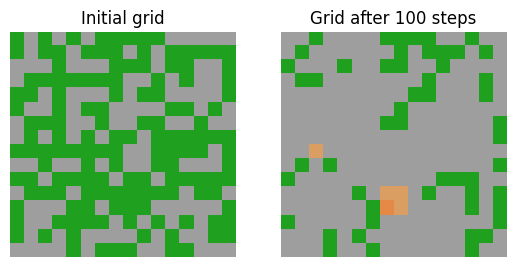

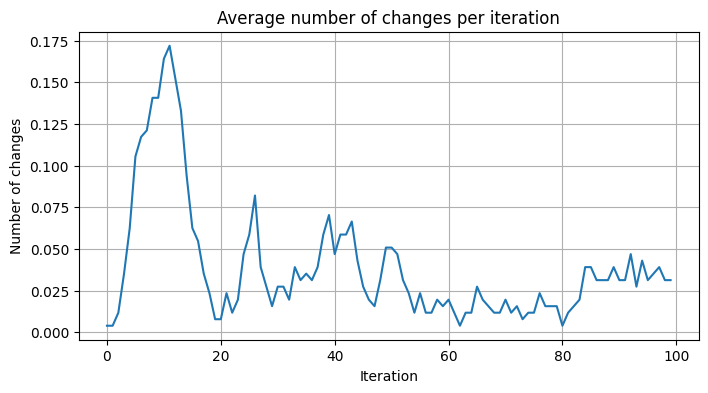

In [5]:
# For the whole exercise, use these properties of the spreading process
grid_dim = 16
init_tree_density = .6
lightning_prob = .01
growth_prob=.01

rng = np.random.RandomState(seed=34)
# ... your code for 1b  here.

step_number = 100

grid = initialize_grid(grid_dim, init_tree_density, rng)

visualize_grid(grid, plt.subplot(1, 2, 1), "Initial grid")

it_change = []

for _ in range(step_number):
    grid_new = step(grid, growth_prob, lightning_prob, rng=rng)
    it_change.append(np.sum(grid != grid_new)/grid_dim**2)
    grid = grid_new

visualize_grid(grid, plt.subplot(1, 2, 2), f"Grid after {step_number} steps")

trees_number = np.sum(grid == TREE)
print(f"Number of trees after {step_number} steps: {trees_number}")

plt.figure(figsize=(8, 4))
plt.plot(it_change)
plt.title("Average number of changes per iteration")
plt.xlabel("Iteration")
plt.ylabel("Number of changes")
plt.grid()
plt.show()

---

Our goal is to learn the deterministic part $F$ of the process using a neural network, so that given knowledge $G$ and the matrices $M$ we can simulate the process truthfully.

To generate some training data, we use the Dataset class in the following to generate pairs of $(\mathbf{\bar{X_t}}, \bar{F(X_{t})})$, so that we can learn $F$ in a supervised manner.
Note that by $\bar{\mathbf{X}} \in K^{s^2}$ we mean the flattened 1D version of the 2D grid.

In [6]:
class FireDataset(Dataset):

    def __init__(self, grid_dim: int, init_tree_density: float,
                 growth_prob: float, lightning_prob: float,
                 n_inits: int = 100, steps: int = 500, seed: int = 0):

        self.grid_dim = grid_dim
        self.growth_prob = growth_prob
        self.lightning_prob = lightning_prob
        self.init_tree_density = init_tree_density

        rng = np.random.default_rng(seed)

        before_list = []
        after_list = []

        for _ in range(n_inits):
            grid = initialize_grid(grid_dim,init_tree_density,rng)

            for _ in range(steps):
                next_det = spread_fire(grid)
                next_grid, _, _ = strike_lightning_and_grow_trees(
                    next_det, self.growth_prob, self.lightning_prob, rng
                )

                before_list.append(grid.copy())
                after_list.append(next_det.copy())

                grid = next_grid

        self.before_list = np.array(before_list, dtype=int)
        self.after_list  = np.array(after_list,  dtype=int)

    def __len__(self):
        return len(self.before_list)

    def __getitem__(self, idx):
        before = torch.tensor(self.before_list[idx], dtype=torch.long).flatten()
        after  = torch.tensor(self.after_list[idx],  dtype=torch.long).flatten()
        return before, after

*Exercise 2 (3 pts):*

a) Explain in max 2 sentences what the parameters `n_inits` and `steps` do.

b) Given your knowledge of the update function from 1a, explain in max 3 sentences why you would want to set the value of steps to something larger than 1 when you use the dataset to train your model. Consider the example video of the process we gave you.

c) Generate a dataset with the parameters below (and the ones you used to generate the process) and split it into training and test using `random_split` imported at the very top of this document.

---

*Answer 2a*: 

`n_inits` defines the number of independent grid samples (data points) created for the dataset. 

`steps` determines the duration of the simulation applied to each of these initial grids to generate the time series.

*Answer 2b*: 

If `steps` were 1, the model would only observe the immediate reaction to a random initialization, missing the structured patterns of spreading fire fronts. Increasing `steps` allows the system to evolve into diverse, realistic configurations (such as established fires and regenerating forests) that are not present at $t=0$ as can be seen in the video example. This ensures the model learns the full dynamics of the cycle rather than just the initialization artifacts.

In [7]:
# Create the dataset
n_inits = 200
steps = 10
seed = 42

dataset  = FireDataset(
    grid_dim, init_tree_density,
    growth_prob, lightning_prob,
    n_inits=n_inits, steps=steps, seed=seed
)

# Split the dataset into train, test, and validation sets
train_ratio, val_ratio = 0.7, 0.3
train_dataset, val_dataset = random_split(
    dataset,
    [math.floor(len(dataset) * train_ratio),
     len(dataset) - math.floor(len(dataset) * train_ratio)]
)

---

### Learning Fire Dynamics using a transformer

Now we need to define the neural network architecture we train.
We will use an adaption of the small transformer from Exercise 12.
Each cell from the grid will correspond to a single token, and the alphabet is $\{$ EMPTY, TREE, LIGHTNING, FIRE_SMALL, FIRE_LARGE $\}$, and we will predict a new sequence, where the goal is to have it correspond to the next time step.

> At this point we highly recommend that you complete Exercise 12 before you go any further.

Our architecture will be as follows
1. Embedding (n_classes x model_dim)
2. PositionalEncoding
3. DotProductAttention
4. LayerNorm
5. Linear (model_dim -> n_hidden)
6. ReLU
7. Linear (n_hidden -> n_classes)

*Exercise 3 (1 pts):*

a) Complete the code below, to make sure you understood the input sizing and dataset size.

b) After applying the Embedding layer (nn.Embedding) to an input $\bar{\mathbf{X}} \in K^{s^2}$, which dimension does your embedded input sequence have? (use the parameters set below)

---

In [8]:
seq_len = grid_dim * grid_dim
num_samples = len(dataset) # total number of samples in the dataset
num_samples_train = len(train_dataset)
num_samples_val = len(val_dataset)
model_dim = 32
n_hidden = 128

print(f"Number of training samples: {num_samples}")
print(f"Number of training samples: {num_samples_train}")
print(f"Number of validation samples: {num_samples_val}")
print(f"Sequence length: {seq_len}")

Number of training samples: 2000
Number of training samples: 1400
Number of validation samples: 600
Sequence length: 256


*Answer 3b:* 

The embedding layer functions as a learnable lookup table that maps discrete tokens (integer indices representing cell states) to continuous dense vectors. Given the parameters provided (`grid_dim` = 16, `model_dim` = 32), the input sequence length `seq_len` is $s^2 =16×16=256$.

Input shape: (`batch_size`, `seq_len`)

Output shape: (`batch_size`, `seq_len`, `model_dim`)

So after embedding, your input tensor has 3 dimensions: (`batch_size`, `seq_len`, `model_dim`). That means, the first layer of a model that processes such categorial one-hot encodings has to be of size $W_{\mathrm{emb}} \in \mathbb{R}^{\text{\rm n\_classes} \times \text{\rm model\_dim}}$, where `n_classes` = 5 is the vocabulary size and `model_dim` = 32 is the model dimension for further processing. When the remainder of the model architecture is added and the model is trained on a given task, the weights $W_{\mathrm{emb}}$ are trained along with other parameters of the model.

---

In [9]:
# provided by us for later use, copy from Exercise 12
class DotProductAttention(nn.Module):
  def __init__(self, model_dim):
    super(DotProductAttention, self).__init__()

    self.model_dim = model_dim

    self.W_Q = nn.Parameter(torch.empty(model_dim, model_dim))
    self.W_K = nn.Parameter(torch.empty(model_dim, model_dim))
    self.W_V = nn.Parameter(torch.empty(model_dim, model_dim))

    nn.init.kaiming_uniform_(self.W_Q.T, a=math.sqrt(5))
    nn.init.kaiming_uniform_(self.W_K.T, a=math.sqrt(5))
    nn.init.kaiming_uniform_(self.W_V.T, a=math.sqrt(5))

    self.attn_probs = None # we want to readout the attention matrix later

  def forward(self, x):
    Qx =  x @ self.W_Q
    Kx = x @ self.W_K
    Vx = x @ self.W_V

    attn_scores = torch.matmul(Qx,Kx.transpose(-2,-1)) / math.sqrt(self.model_dim)
    attn_probs = torch.softmax(attn_scores,dim=-1)
    x = torch.matmul(attn_probs,Vx)

    self.attn_probs = attn_probs
    return x

### Positional Encodings

Our architecture is identical to that used in the Histogram task from Exercise 12, except that we add positional encodings to the input tokens.
Positional encodings $\mathbf P \in \mathbb{R}^{\mathrm{seq\_len} \times \mathrm{model\_dim}} $ are added to the embedded input sequence.
There are many options to choose $\mathbf  P$, theoretically it suffices to just set a different vector for every position to be able to distinguish them. Sometimes $\mathbf P$ are learned parameters, but usually the goal is to insert some positional prior into the model that is not learned, but chosen carefully.

Below we provide sinusodal positional encodings for 1D sequences (`get_1d_sinusoidal_pos_emb`).

*Exercise 4 (4 pts):*

a) Explain in two sentences what you would expect the model to learn for the given task if it did not have access to positional embeddings, and why.

b) For the positional encodings obtained from get_1d_sinusoidal_pos_emb(seq_len, model_dim) with seq_len=30, plot the dot product of the encoding of position 5 with all other positions as a line plot for model_dim=16,32,64,128,256. What do you observe?

c) Complete the positional encoding module, so that it takes in the given parameters and stores the positional encodings, and in the forward pass adds the positional encoding to each sequence in the batch.

---

*Answer 4a:* 

Without positional embeddings, the model would process the grid as an unordered 'bag of cells' (permutation invariant), effectively losing all spatial structure. Consequently, it would fail to learn the fire spreading dynamics, as it could not determine which cells are neighbors to apply the local propagation rules (Von Neumann neighborhood).

Below, we provide a function that generates $\mathbf P$ for a given sequence length and model dimension.

In [10]:
def get_1d_sinusoidal_pos_emb(seq_len, model_dim):
    """
    Standard Transformer sinusoidal embeddings over a 1D sequence
    of length seq_len.
    Returns shape (seq_len, model_dim).
    model_dim must be even.
    """
    assert model_dim % 2 == 0

    position = torch.arange(seq_len, dtype=torch.float32).unsqueeze(1)  # (seq_len,1)
    div_term = torch.exp(torch.arange(0, model_dim, 2).float()
                         * -(math.log(10000.0) / model_dim))

    pe = torch.zeros(seq_len, model_dim)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe   # (seq_len, model_dim)

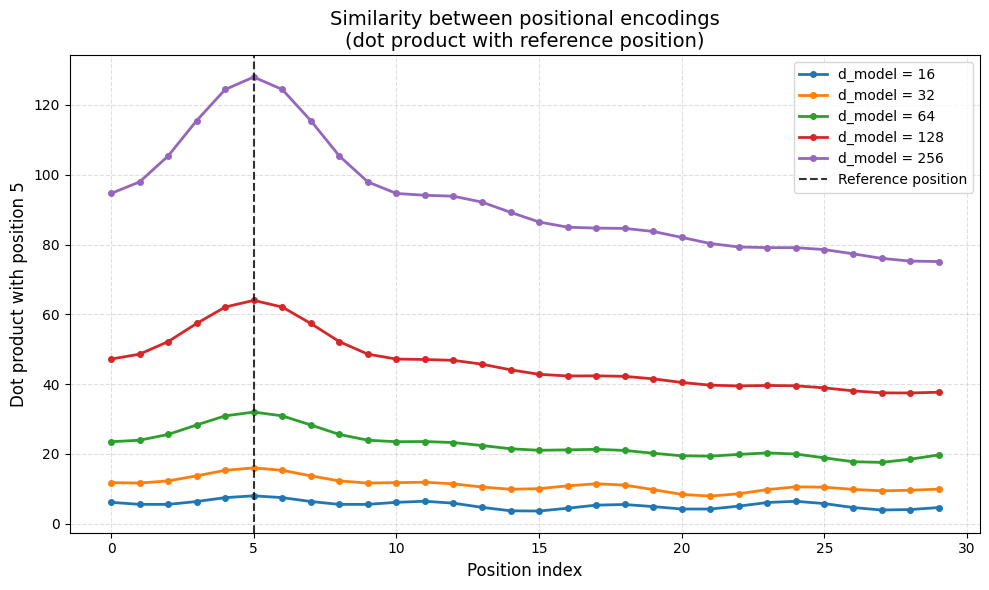

In [11]:
## Your answer for 4b)
seq_len_ex = 30
model_dim_ex = [16, 32, 64, 128, 256]
position = 5

plt.figure(figsize=(10, 6))

all_values = []

for md in model_dim_ex:
    P = get_1d_sinusoidal_pos_emb(seq_len_ex, md)
    dot_products = P[position] @ P.T
    all_values.append(dot_products)

    plt.plot(
        np.arange(seq_len_ex),
        dot_products,
        marker="o",
        markersize=4,
        linewidth=2,
        label=f"d_model = {md}"
    )

ymax = np.max(all_values)
plt.axvline(
    position,
    color="black",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label="Reference position"
)

plt.xlabel("Position index", fontsize=12)
plt.ylabel(f"Dot product with position {position}", fontsize=12)
plt.title(
    "Similarity between positional encodings\n(dot product with reference position)",
    fontsize=14
)

plt.legend(frameon=True)
plt.grid(alpha=0.4, linestyle="--")
plt.tight_layout()
plt.show()

*Answer 4b:* 

For the positional encodings obtained from `get_1d_sinusoidal_pos_emb`, we plot the dot product between the encoding at position $5$ and all others across varying model dimensions.

Observations:
- Magnitude: The dot product values generally increase with `model_dim` (as we are summing over more components).
- Locality (The Peak): A peak always appears at position $5$ (self-similarity). As `model_dim` increases, this peak becomes significantly sharper and narrower.
- Resolution: At lower dimensions (16–32), the curve is flatter, indicating that the model struggles to differentiate position $5$ from its neighbors (low positional resolution). At higher dimensions (128+), the sharp decay around the peak allows the model to distinguish distinct positions with high precision.

In [12]:
class PositionalEmbedding1D(nn.Module):
    def __init__(self, grid_dim: int, model_dim: int):
        """
        Creates 1D positional embeddings over a flattened grid.
        """
        super().__init__()
        self.pos_emb = get_1d_sinusoidal_pos_emb(grid_dim * grid_dim, model_dim)

    def forward(self, x):
        """
        x: (batch_size, seq_len, model_dim)
        Adds positional embeddings to each element.
        """
        return x + self.pos_emb.unsqueeze(0).to(x.device)

---

We are now ready to define the full architecture, setup our datasets and train the model. We provide the training function for you, but is exactly the same as in Exercise session 12.

*Exercise 5 (4 pts):*

a) Define your transformer, by filling the correct dimensions below.

b) Train your model on your training data using the train loop we provide.

c) Plot the train and validation losses (y-axis in logarithm). Does the model generalize? What accuracy do you get? Is this satisfactory?


In [13]:
def train(transformer, n_classes, train_dataloader, val_dataloader,lr = 0.001,n_epochs = 300):
    # DO NOT CHANGE THIS FUNCTION
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(transformer.parameters(), lr=lr, betas=(0.9, 0.98), eps=1e-9)

    train_losses = []
    val_losses = []
    val_acc = []

    for epoch in range(n_epochs):

            epoch_loss = 0.0

            for X, y in train_dataloader:
                optimizer.zero_grad()

                output = transformer(X)
                loss = criterion(output.contiguous().view(-1, n_classes), y.contiguous().view(-1))

                epoch_loss += loss.item()

                loss.backward()
                optimizer.step()

            epoch_loss /= len(train_dataloader)
            train_losses.append(epoch_loss)

            # Evaluate on the test set every epoch
            with torch.no_grad():
                val_loss = 0.0
                acc = 0.0
                for X, y in val_dataloader:
                    output = transformer(X)
                    pred = output.argmax(axis=-1)
                    loss = criterion(output.view(-1,n_classes), y.view(-1))
                    acc += torch.mean((pred.view(-1)==y.view(-1)).float()).item()
                    val_loss+=loss.item()
                val_loss /= len(val_dataloader)
                acc /= len(val_dataloader)

                val_losses.append(val_loss)
                val_acc.append(acc)

            if epoch % 10 == 0:
                print(f'[Epoch {epoch:02}] Train loss = {epoch_loss:.5f} :: Val loss {val_loss:.5f} :: Val accuracy {acc*100:.2f}')

    return transformer, train_losses, val_losses, val_acc

---

In [14]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)

model_dim = 32
n_hidden = 128

# FILL WITH CORRECT DIMENSIONS
transformer = nn.Sequential(nn.Embedding(n_classes, model_dim),
            PositionalEmbedding1D(grid_dim, model_dim),
            DotProductAttention(model_dim),
            nn.LayerNorm(model_dim),
            nn.Linear(model_dim, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_classes))

In [15]:
# Train your model and plot the loss curves
transformer, train_losses, val_losses, val_acc = train(transformer, n_classes, train_dataloader, val_dataloader)

[Epoch 00] Train loss = 0.72771 :: Val loss 0.34058 :: Val accuracy 90.29
[Epoch 10] Train loss = 0.13235 :: Val loss 0.12588 :: Val accuracy 95.30
[Epoch 20] Train loss = 0.12431 :: Val loss 0.11836 :: Val accuracy 95.29
[Epoch 30] Train loss = 0.11755 :: Val loss 0.11361 :: Val accuracy 95.33
[Epoch 40] Train loss = 0.11384 :: Val loss 0.10989 :: Val accuracy 95.36
[Epoch 50] Train loss = 0.10947 :: Val loss 0.10541 :: Val accuracy 95.40
[Epoch 60] Train loss = 0.10513 :: Val loss 0.10204 :: Val accuracy 95.49
[Epoch 70] Train loss = 0.10220 :: Val loss 0.09966 :: Val accuracy 95.51
[Epoch 80] Train loss = 0.10048 :: Val loss 0.09927 :: Val accuracy 95.52
[Epoch 90] Train loss = 0.09887 :: Val loss 0.09804 :: Val accuracy 95.43
[Epoch 100] Train loss = 0.09685 :: Val loss 0.09489 :: Val accuracy 95.62
[Epoch 110] Train loss = 0.09501 :: Val loss 0.09413 :: Val accuracy 95.61
[Epoch 120] Train loss = 0.09285 :: Val loss 0.09081 :: Val accuracy 95.80
[Epoch 130] Train loss = 0.08769 ::

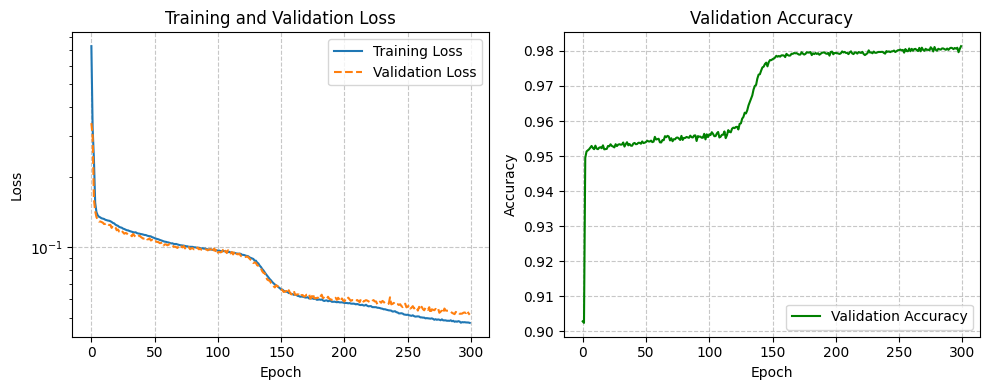

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Training and Validation Loss
ax1.plot(train_losses, label='Training Loss', linestyle='-')
ax1.plot(val_losses, label='Validation Loss', linestyle='--')
ax1.set_yscale('log')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.7, linestyle='--')
ax1.legend()

# Validation Accuracy
ax2.plot(val_acc, label='Validation Accuracy', color='green')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(alpha=0.7, linestyle='--')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

*Answer 5c:* 

Does the model generalize? Yes. We observe that both the training and validation losses decrease steadily over epochs on the logarithmic scale. Crucially, the validation loss tracks the training loss closely without diverging, which indicates that the model is not overfitting and generalizes well to unseen data.

Accuracy and Satisfaction: The model reaches an accuracy of over $0.98$. This is a satisfactory result, as it indicates less than $2\%$ error. Nuance: While $98\%$ is high, we note that in cellular automata, many cells remain unchanged between steps (high baseline accuracy). However, exceeding this baseline confirms that the model has successfully learned both:
- The stability rules (predicting "no change" correctly for the majority of cells).
- The dynamic rules (predicting fire spread and regeneration), allowing it to surpass the baseline accuracy of a trivial identity function.

Learning Dynamics: We distinguish two regimes in the learning curve:
- Rapid Adaptation: In the first few epochs, loss drops sharply as the model learns the dominant static rules (e.g., empty cells stay empty).
- Learning Determinic Phase: A steady improvement where the model refines its understanding of the deterministic fire spread (Von Neumann neighborhood).

---

*Exercise 6 (5 pts):*
The transformer was trained to predict the function $F$, i.e. the deterministic part of the update from a given input. However, to predict the whole evolution correctly, we need to understand whether the errors incured in a single step accumulate significantly over time.

This means that we will "roll out" the model and compare it to the ground truth. This means that for a given initialization $\mathbf X_0$, we will apply both $F(\mathbf X_0)$ and $F^{\rm transformer}(\mathbf X_0)$. Then at every time step this is followed by appling $G$ with the randomly sampled $ M^{\rm growth} , M^{\rm lightning}$, where we use the same for generating the ground truth and predicted evolution.
In the case that $F^{\rm transformer}$ matches $F$, the evolution of the process will be identicall throughout.

For this rollout, we will measure several statistics for 100 time steps:

a) The average number of errors over the time steps.

b) The **logarithm** of the average number of errors per grid cell (use imshow) in the whole roll-out, make sure to reshape into a grid again.

c) How does the largest error over time compare with the validation accuracy?

Remember: In order to compare the ground truth and the prediction from the model, you need to apply the SAME randomness throughout the process. You can do this by accessing the lightning and growth masks that are generated in the update function $G$ and applying it manually. It may help to visualize your model during debugging to make sure that this is the case.

---

In [17]:
def rollout_and_collect_data(model, init_grid, steps, growth_prob, lightning_prob):
    model.eval()
    grid_dim = init_grid.shape[0]

    pred_grid = init_grid.copy()
    true_grid = init_grid.copy()

    errors = []

    for _ in range(steps):
        input_tensor = torch.tensor(pred_grid.flatten(), dtype=torch.long).unsqueeze(0)

        with torch.no_grad():
            output = model(input_tensor)

        pred_grid = output.argmax(axis=-1).detach().numpy().reshape(grid_dim, grid_dim) # should have shape of the 2d grid again (grid_dim x grid_dim)

        # Ground truth next step
        true_grid, growth, lightning = step(true_grid, growth_prob=growth_prob, lightning_prob=lightning_prob, extra_info=True)

        # Apply growth/lightning effects on pred_grid for fair comparison
        # TODO: apply stochastic part to predicted grid
        pred_grid[(pred_grid == TREE) & lightning] = LIGHTNING
        pred_grid[(pred_grid == EMPTY) & growth] = TREE

        # TODO: compare the prediction and the ground truth
        errors.append((pred_grid != true_grid).astype(int))

    errors = np.array(errors)

    return {
        "mistakes_per_step": errors.mean(axis=(1,2)),  # average over the grid axes
        "error_locations": errors.mean(axis=0), # average over the time axis
    }


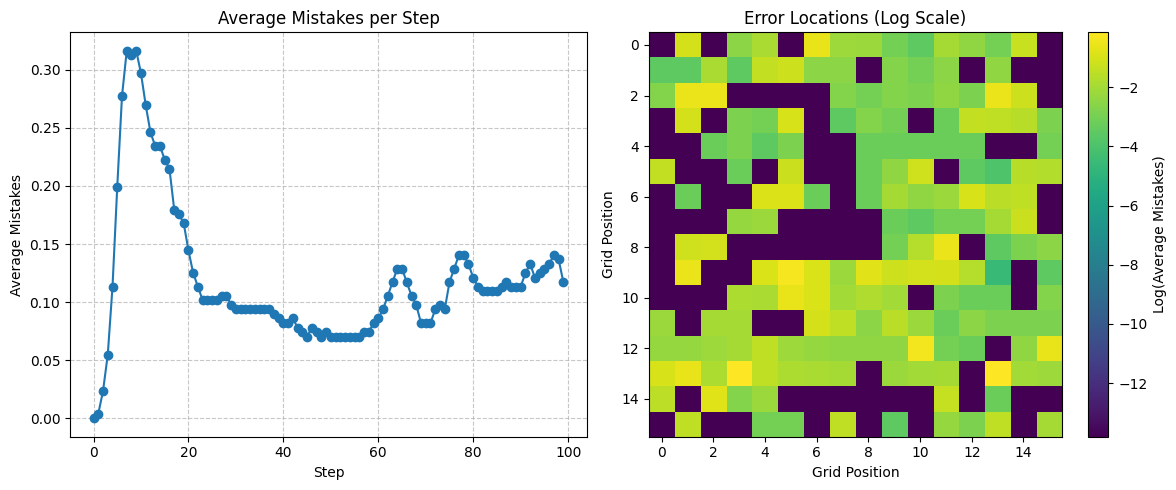

In [18]:
init_grid = initialize_grid(grid_dim, init_tree_density, rng=np.random.RandomState(13))
data = rollout_and_collect_data(transformer, init_grid, 100, growth_prob, lightning_prob)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Graphique 1 : Courbe classique ---
ax1.plot(data["mistakes_per_step"], marker='o')
ax1.set_title("Average Mistakes per Step")
ax1.set_xlabel("Step")
ax1.set_ylabel("Average Mistakes")
ax1.grid(alpha=0.7, linestyle='--')

# --- Graphique 2 : Matrice en Log ---
# 1. On ajoute une petite valeur (epsilon) pour éviter log(0) qui fait planter
epsilon = 1e-6 
# 2. On applique le log mathématiquement sur les données
log_data = np.log(data["error_locations"].T + epsilon)

im = ax2.imshow(log_data, aspect='auto', cmap='viridis')

ax2.set_title("Error Locations (Log Scale)")
ax2.set_xlabel("Grid Position")
ax2.set_ylabel("Grid Position")

# La barre de couleur indique maintenant le Log des erreurs
fig.colorbar(im, ax=ax2, label='Log(Average Mistakes)')

plt.tight_layout()
plt.show()

*Answer 6c:* 

The largest error observed during the rollout is significantly higher than the validation error (1−accuracy $\approx 2\%$).

While the validation accuracy is high ($\approx 98\%$), it only measures performance for a single step given ground truth inputs. In the rollout, however, the model is fed its own previous predictions (auto-regressive generation). Small errors made by the model (e.g., failing to ignite a neighbor) accumulate over time, causing the predicted trajectory to diverge from the ground truth. This phenomenon is known as covariate shift or error accumulation.

Observations typically seen:
- $t=0$: Error is $0$ (identical initialization).
- $t=10$ to $50$: Error grows rapidly as the fire spreads differently in the two versions.
- $t=100$: We observe that the error may stabilise or decrease.

---

## Defining Alternative Positional Encodings

In order to improve the model we learned, we can use the fact that the dynamics happen in 2D. So far, the positional encodings are only encoding a 1D setting, and do not account for a 2D structure.
One way of encoding 2D euclidean space is simply having separate encodings for the column and row-space, and concatenating them.
That is, $PE_{\mathrm{row}} \in \mathbb{R}^{\mathrm{seq\_len} \times \mathrm{model\_dim}/2}$ and $PE_{\mathrm{col}} \in \mathbb{R}^{\mathrm{seq\_len} \times \mathrm{model\_dim}/2}$. The final positional embedding is then simply their concatenation.

In addition to this type of embedding, we provide you with another type of embedding, that is designed for a Torus (a grid that wraps around its edges) in `get_2d_torus_pos_emb`.

*Exercise 7 ( 4 pts):*

a) Generate 2D sinusodal encodings using the previously defined get_1d_sinusoidal_pos_emb, by concatenating row and column encodings. The final return should be of dimensions (grid_dim*grid_dim, model_dim), so it can be directly applied to the flattened grid.

b) Repeat your result for getting 2D embeddings of 1D Torus embeddings.

c) Create encodings for a model dimension of 16, and plot the value of the dot product between the encoding of the item at a position of your choice (e.g. 34 of the flattened array) and all other encodings, reshaped to an imshow. Mark the comparison position on the plotted 2D grid. Compare this plot for 1D embeddings, 2D embeddings, and the 2D Torus embeddings.
What differences do you observe? Which encoding do you expect to work best for learning the fire spread?

d) For both 2D sinusodal and 2D Torus encodings, complete their respective torch modules.

---

In [19]:
def get_2d_sinusoidal_pos_emb(grid_dim, model_dim):
    """
    Create 2D sinusoidal positional embeddings of shape (grid_dim*grid_dim, model_dim).
    model_dim should be even (split evenly for row and col).
    """
    assert model_dim % 2 == 0, "model_dim must be even"

    pos_emb = torch.zeros((grid_dim * grid_dim, model_dim))
    half_dim = model_dim // 2
    row_emb = get_1d_sinusoidal_pos_emb(grid_dim, half_dim)  # (grid_dim, half_dim)
    col_emb = get_1d_sinusoidal_pos_emb(grid_dim, half_dim)  # (grid_dim, half_dim)
    for r in range(grid_dim):
        for c in range(grid_dim):
            pos = r * grid_dim + c
            pos_emb[pos, :half_dim] = row_emb[r]
            pos_emb[pos, half_dim:] = col_emb[c]

    return pos_emb # (grid_dim*grid_dim, model_dim)

In [20]:
def get_1d_torus_sinusoids(seq_length, model_dim):
        pos = torch.arange(seq_length).unsqueeze(1)
        k   = torch.arange(model_dim//2).unsqueeze(0)
        freq = 2 * math.pi * k / seq_length
        angles = freq * pos

        emb = torch.zeros(seq_length, model_dim)
        emb[:, 0::2] = torch.sin(angles)
        emb[:, 1::2] = torch.cos(angles)
        return emb

# Update from first moodle version: Renames this function from get_2d_sinusoidal_pos_emb to get_2d_torus_pos_embs
def get_2d_torus_pos_emb(grid_dim, model_dim):
        """
        
        Create 2D torus positional embeddings of shape (grid_dim*grid_dim, model_dim).
        model_dim should be even (split evenly for row and col).
        """
        assert model_dim % 2 == 0, "model_dim must be even"

        pos_emb = torch.zeros((grid_dim * grid_dim, model_dim))
        half_dim = model_dim // 2
        row_emb = get_1d_torus_sinusoids(grid_dim, half_dim)  # (grid_dim, half_dim)
        col_emb = get_1d_torus_sinusoids(grid_dim, half_dim)  # (grid_dim, half_dim)
        for r in range(grid_dim):
                for c in range(grid_dim):
                        pos = r * grid_dim + c
                        pos_emb[pos, :half_dim] = row_emb[r]
                        pos_emb[pos, half_dim:] = col_emb[c]

        return pos_emb

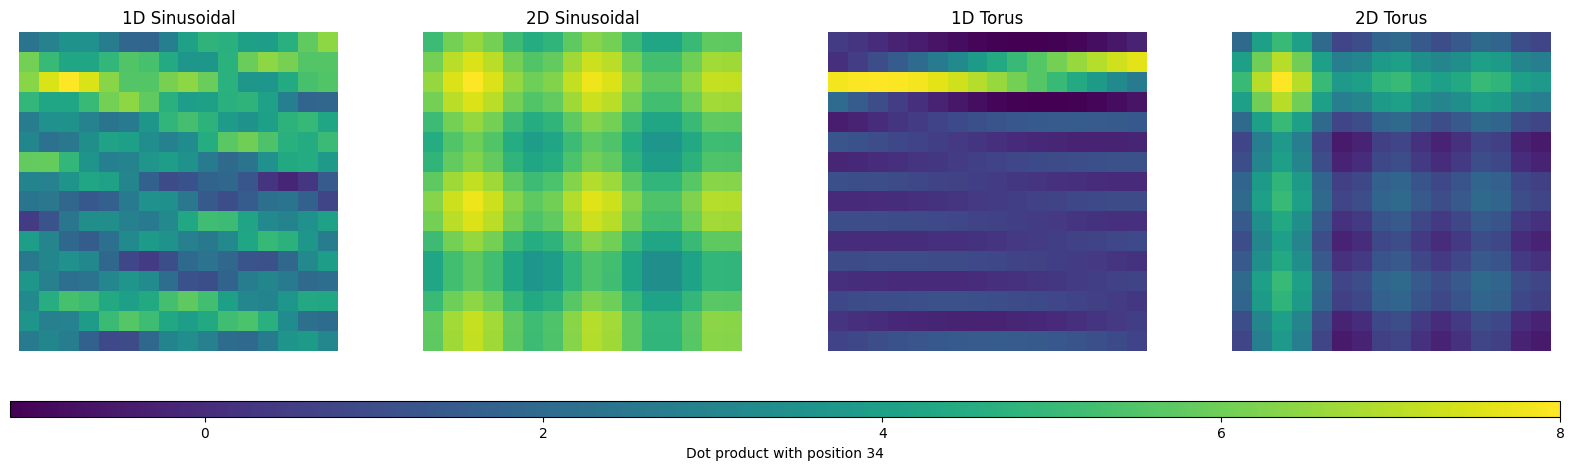

In [21]:
model_dim_ex = 16 
position = 34
seq_len_ex = grid_dim * grid_dim

pe_1d_sinus = get_1d_sinusoidal_pos_emb(seq_len_ex, model_dim_ex)
pe_2d_sinus = get_2d_sinusoidal_pos_emb(grid_dim, model_dim_ex)
pe_1d_torus = get_1d_torus_sinusoids(seq_len_ex, model_dim_ex)
pe_2d_torus = get_2d_torus_pos_emb(grid_dim, model_dim_ex)

dot_products_1d_sinus = pe_1d_sinus[position] @ pe_1d_sinus.T 
dot_products_2d_sinus = pe_2d_sinus[position] @ pe_2d_sinus.T
dot_products_1d_torus = pe_1d_torus[position] @ pe_1d_torus.T
dot_products_2d_torus = pe_2d_torus[position] @ pe_2d_torus.T

dot_list = [dot_products_1d_sinus, dot_products_2d_sinus, dot_products_1d_torus, dot_products_2d_torus]
labels = ["1D Sinusoidal", "2D Sinusoidal", "1D Torus", "2D Torus"]

seq_len_ex = dot_list[0].shape[0]
grid_size = int(np.sqrt(seq_len_ex))

# Créer un gridspec avec 2 lignes : 1 pour les images, 1 pour la colorbar
fig = plt.figure(figsize=(20, 5))
gs = fig.add_gridspec(2, 4, height_ratios=[1, 0.05], hspace=0.3)

vmin = min([dp.min() for dp in dot_list])
vmax = max([dp.max() for dp in dot_list])

axes = []
for i in range(4):
    ax = fig.add_subplot(gs[0, i])
    img = dot_list[i].reshape(grid_size, grid_size)
    im = ax.imshow(img, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(labels[i])
    ax.axis('off')
    axes.append(ax)

# Ajouter la colorbar horizontale sur toute la largeur
cbar_ax = fig.add_subplot(gs[1, :])  # ligne 1, toutes les colonnes
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label(f'Dot product with position {position}')

plt.show()

*Answer 7c:* 

Differences observed:
- 1D Embedding: The heatmap shows high similarity only along the horizontal axis (immediate neighbors in the flattened sequence). Vertical neighbors, which are `grid_dim` indices away in the flattened array, have very low dot products. The model effectively sees vertical neighbors as being "far apart," breaking the spatial continuity of the grid.
- 2D Sinusoidal: The heatmap reveals a localized "blob" or cross shape around the target position. High similarity is observed for both horizontal and vertical neighbors, correctly capturing the Euclidean 2D structure. However, it treats the edges as boundaries (no wrapping).
- 2D Torus: Similar to the 2D sinusoidal embedding, it captures local 2D structure. However, it distinguishes itself at the boundaries: it correctly encodes that the left edge is connected to the right edge and the top to the bottom (periodic boundary conditions).

Which encoding is best? I expect the 2D Torus embedding to work best for learning the fire spread.

Reasoning:
- Spatial Locality: The fire spreading rule depends on the Von Neumann neighborhood (up, down, left, right). Unlike the 1D embedding, both 2D embeddings naturally preserve this spatial locality, allowing the Transformer's attention mechanism to easily "attend" to relevant neighbors.
- Topology: The simulation typically uses periodic boundary conditions (implied by the introduction of the Torus embedding). The Torus embedding is the only one that naturally represents this wrapping, ensuring that fire spreading across edges is learned as easily as spreading in the center.

In [22]:
class PositionalEmbedding2D(nn.Module):
    def __init__(self, grid_dim: int, model_dim: int):
        super().__init__()
        self.pos_emb = get_2d_sinusoidal_pos_emb(grid_dim, model_dim)

    def forward(self, x):
        return x + self.pos_emb.unsqueeze(0).to(x.device)

class PositionalEmbedding2DTorus(nn.Module):
    def __init__(self, grid_dim: int, model_dim: int):
        super().__init__()
        self.pos_emb =  get_2d_torus_pos_emb(grid_dim, model_dim)

    def forward(self, x):
        return x + self.pos_emb.unsqueeze(0).to(x.device) # shape (1, seq_len, model_dim)

---

## Learning with different positional encodings

In this final section, you will train transformers using the three different types of positional encodings.

*Exercise 8 (6 pts):*

a) Create the three types of transformers, replacing only the positional encoding layer, and train them using the default settings in the train loop we provided (about 15min without GPU, if the model is very spiky at low losses it is ok). If you want, you can continue using 1D positional encoding transformer you trained before.

b) Compare and plot the evolution of the three train and test losses, with the loss in log-scale - which model does best?

c) Reuse your rollout_and_collect_data code, but this time average your results over 200 different initializations. Plot the average error over grid and initializations for 100 time steps (in a single plot for all three models), and again the **logarithm** of the average error over time and initializations for each grid cell as an imshow. What is the difference in particular between the two types of 2D embeddings?

d) Which model would you select for final use?


---

In [23]:
transformer_1D_sinus = nn.Sequential(nn.Embedding(n_classes, model_dim),
                        PositionalEmbedding1D(grid_dim, model_dim),
                        DotProductAttention(model_dim),
                        nn.LayerNorm(model_dim),
                        nn.Linear(model_dim, n_hidden),
                        nn.ReLU(),
                        nn.Linear(n_hidden, n_classes))

transformer_2d_sinus = nn.Sequential(nn.Embedding(n_classes, model_dim),
                        PositionalEmbedding2D(grid_dim, model_dim),
                        DotProductAttention(model_dim),
                        nn.LayerNorm(model_dim),
                        nn.Linear(model_dim, n_hidden),
                        nn.ReLU(),
                        nn.Linear(n_hidden, n_classes))

transformer_2d_torus = nn.Sequential(nn.Embedding(n_classes, model_dim),
                        PositionalEmbedding2DTorus(grid_dim, model_dim),
                        DotProductAttention(model_dim),
                        nn.LayerNorm(model_dim),
                        nn.Linear(model_dim, n_hidden),
                        nn.ReLU(),
                        nn.Linear(n_hidden, n_classes))

# Train your three models and collect the training/validation losses and accuracies

print("Training 1D Sinusoidal Positional Embedding Model")
# transformer_1D_sinus, train_losses_1d_sinus, val_losses_1d_sinus, val_acc_1d_sinus = train(transformer_1D_sinus, n_classes, train_dataloader, val_dataloader)
transformer_1D_sinus, train_losses_1d_sinus, val_losses_1d_sinus, val_acc_1d_sinus = transformer, train_losses, val_losses, val_acc

print("Training 2D Sinusoidal Positional Embedding Model")
transformer_2d_sinus, train_losses_2d_sinus, val_losses_2d_sinus, val_acc_2d_sinus = train(
    transformer_2d_sinus, n_classes, train_dataloader, val_dataloader
)

print("Training 2D Torus Positional Embedding Model")
transformer_2d_torus, train_losses_2d_torus, val_losses_2d_torus, val_acc_2d_torus = train(
    transformer_2d_torus, n_classes, train_dataloader, val_dataloader
)

Training 1D Sinusoidal Positional Embedding Model
Training 2D Sinusoidal Positional Embedding Model
[Epoch 00] Train loss = 0.67846 :: Val loss 0.32207 :: Val accuracy 90.31
[Epoch 10] Train loss = 0.12932 :: Val loss 0.12331 :: Val accuracy 95.24
[Epoch 20] Train loss = 0.12228 :: Val loss 0.11607 :: Val accuracy 95.27
[Epoch 30] Train loss = 0.10268 :: Val loss 0.09696 :: Val accuracy 95.82
[Epoch 40] Train loss = 0.07198 :: Val loss 0.06890 :: Val accuracy 97.09
[Epoch 50] Train loss = 0.04193 :: Val loss 0.03960 :: Val accuracy 98.66
[Epoch 60] Train loss = 0.02711 :: Val loss 0.02702 :: Val accuracy 99.25
[Epoch 70] Train loss = 0.01939 :: Val loss 0.01879 :: Val accuracy 99.55
[Epoch 80] Train loss = 0.01554 :: Val loss 0.01608 :: Val accuracy 99.63
[Epoch 90] Train loss = 0.01411 :: Val loss 0.01522 :: Val accuracy 99.67
[Epoch 100] Train loss = 0.01313 :: Val loss 0.01342 :: Val accuracy 99.71
[Epoch 110] Train loss = 0.01280 :: Val loss 0.01335 :: Val accuracy 99.70
[Epoch 120

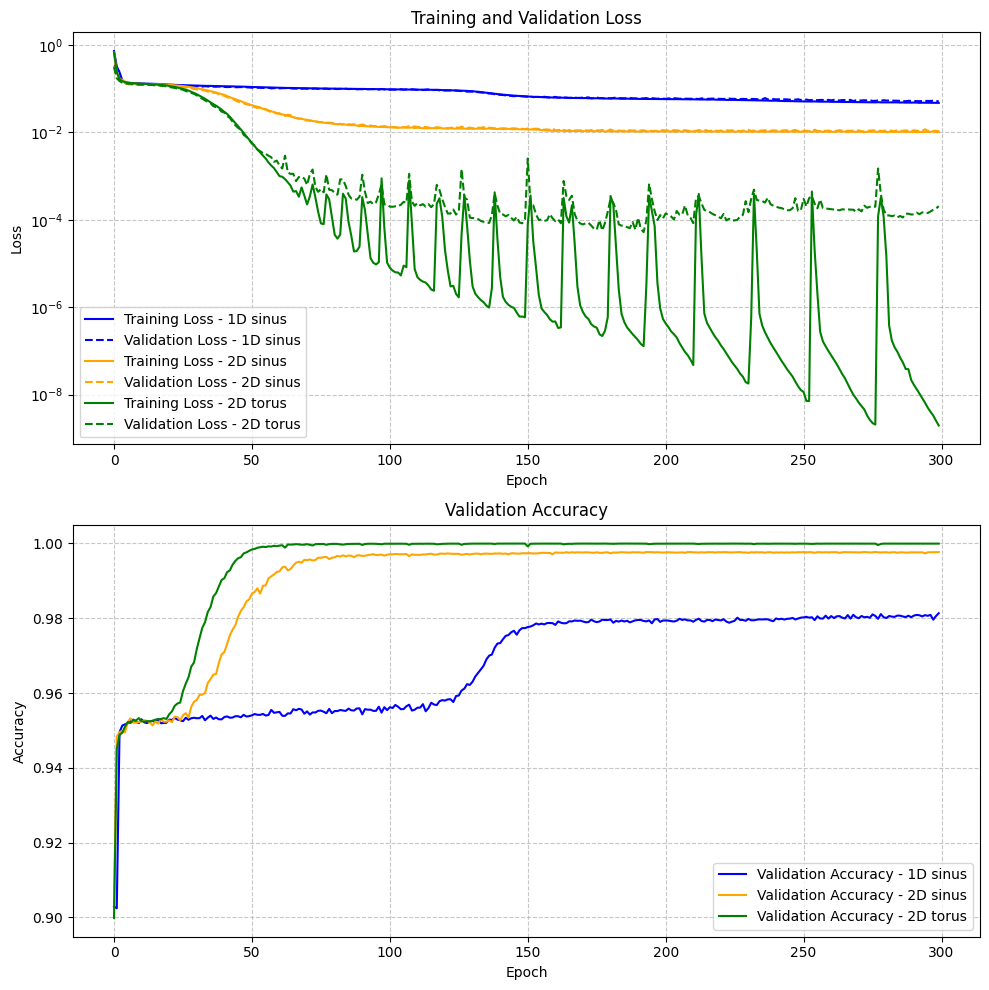

In [24]:
color = ['blue', 'orange', 'green']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Training and Validation Loss
ax1.plot(train_losses_1d_sinus, label='Training Loss - 1D sinus', color='blue')
ax1.plot(val_losses_1d_sinus, label='Validation Loss - 1D sinus', color='blue', linestyle='--')
ax1.plot(train_losses_2d_sinus, label='Training Loss - 2D sinus', color='orange')
ax1.plot(val_losses_2d_sinus, label='Validation Loss - 2D sinus', color='orange', linestyle='--')
ax1.plot(train_losses_2d_torus, label='Training Loss - 2D torus', color='green')
ax1.plot(val_losses_2d_torus, label='Validation Loss - 2D torus', color='green', linestyle='--')
ax1.set_yscale('log')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.7, linestyle='--')
ax1.legend()

# Validation Accuracy
ax2.plot(val_acc_1d_sinus, label='Validation Accuracy - 1D sinus', color='blue')
ax2.plot(val_acc_2d_sinus, label='Validation Accuracy - 2D sinus', color='orange')
ax2.plot(val_acc_2d_torus, label='Validation Accuracy - 2D torus', color='green')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(alpha=0.7, linestyle='--')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

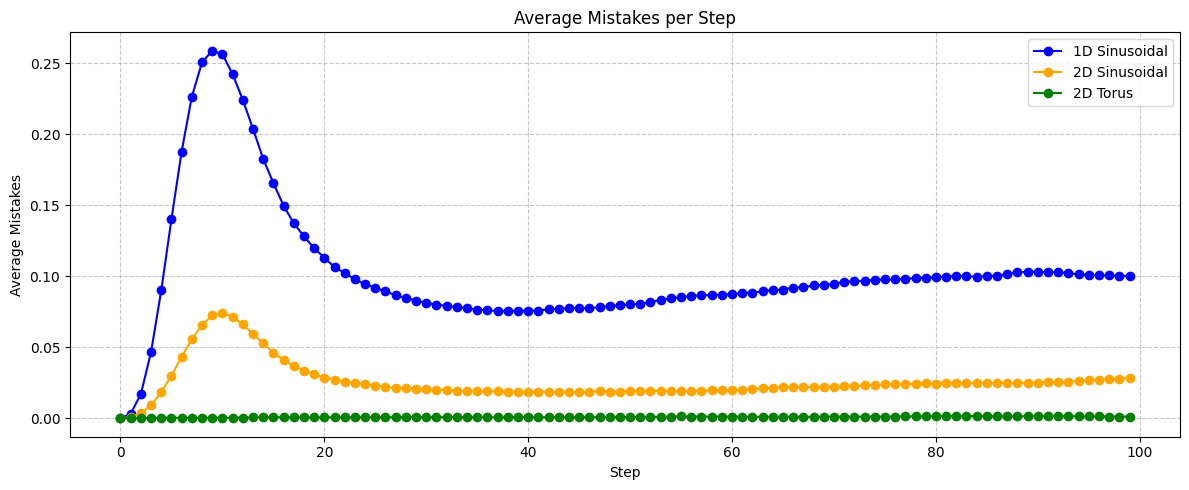

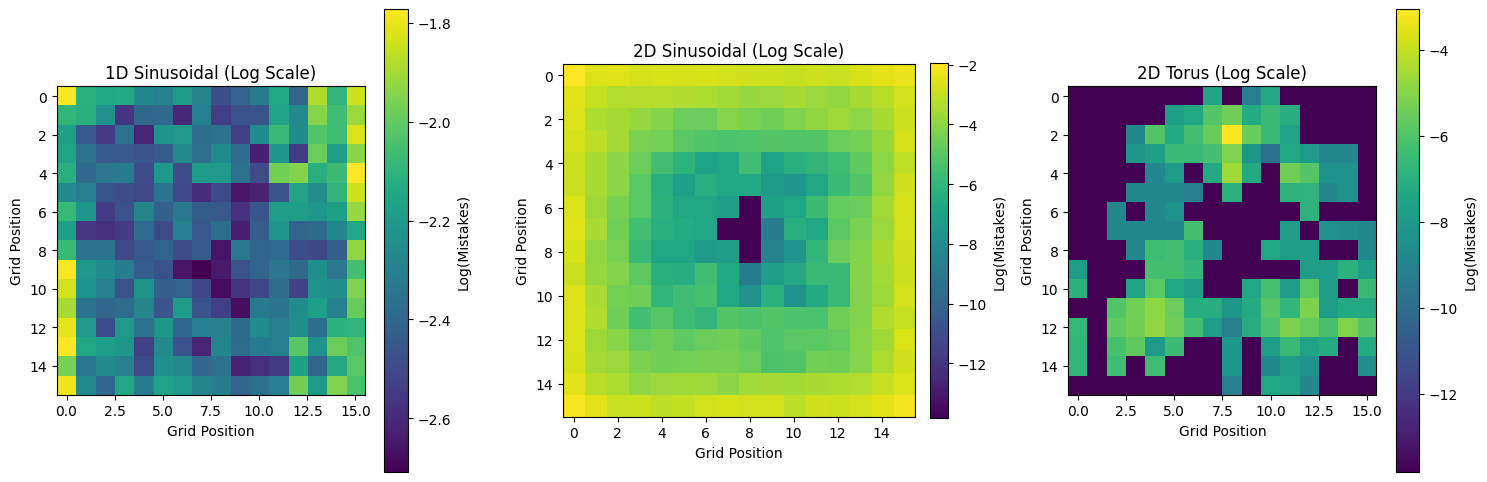

In [26]:
num_init = 200

data_1d_sinus_tab, data_2d_sinus_tab, data_2d_torus_tab = [], [], [] 

for _ in range(num_init):
    init_grid = initialize_grid(grid_dim,init_tree_density)
    data_1d_sinus_tab.append(rollout_and_collect_data(transformer_1D_sinus, init_grid, 100, growth_prob, lightning_prob))
    data_2d_sinus_tab.append(rollout_and_collect_data(transformer_2d_sinus, init_grid, 100, growth_prob, lightning_prob))
    data_2d_torus_tab.append(rollout_and_collect_data(transformer_2d_torus, init_grid, 100, growth_prob, lightning_prob))

data_1d_sinus = {k: np.mean([d[k] for d in data_1d_sinus_tab], axis=0) for k in data_1d_sinus_tab[0]}
data_2d_sinus = {k: np.mean([d[k] for d in data_2d_sinus_tab], axis=0) for k in data_2d_sinus_tab[0]}
data_2d_torus = {k: np.mean([d[k] for d in data_2d_torus_tab], axis=0) for k in data_2d_torus_tab[0]}

plt.figure(figsize=(12, 5))

plt.plot(data_1d_sinus["mistakes_per_step"], marker='o', label='1D Sinusoidal', color='blue')
plt.plot(data_2d_sinus["mistakes_per_step"], marker='o', label='2D Sinusoidal', color='orange')
plt.plot(data_2d_torus["mistakes_per_step"], marker='o', label='2D Torus', color='green')

plt.title("Average Mistakes per Step")
plt.xlabel("Step")
plt.ylabel("Average Mistakes")
plt.grid(alpha=0.7, linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

epsilon = 1e-6 

def get_log_data(data):
    return np.log(data["error_locations"].T + epsilon)

# --- Graphique 1 : 1D Sinusoidal ---
im1 = ax1.imshow(get_log_data(data_1d_sinus), cmap='viridis')
ax1.set_title("1D Sinusoidal (Log Scale)")
ax1.set_xlabel("Grid Position")
ax1.set_ylabel("Grid Position")
fig.colorbar(im1, ax=ax1, label='Log(Mistakes)', fraction=0.046, pad=0.04)

# --- Graphique 2 : 2D Sinusoidal ---
im2 = ax2.imshow(get_log_data(data_2d_sinus), cmap='viridis')
ax2.set_title("2D Sinusoidal (Log Scale)")
ax2.set_xlabel("Grid Position")
ax2.set_ylabel("Grid Position")
fig.colorbar(im2, ax=ax2, label='Log(Mistakes)', fraction=0.046, pad=0.04)

# --- Graphique 3 : 2D Torus ---
im3 = ax3.imshow(get_log_data(data_2d_torus), cmap='viridis')
ax3.set_title("2D Torus (Log Scale)")
ax3.set_xlabel("Grid Position")
ax3.set_ylabel("Grid Position")
fig.colorbar(im3, ax=ax3, label='Log(Mistakes)', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

*Answers 8 b* : which model does best?

Comparison: We compared the training and validation losses of three models: 1D Sinusoidal, 2D Sinusoidal, and 2D Torus.

Observations:
- Overall Performance: The 2D Torus model achieves the lowest training and validation losses, indicating it is the most capable of capturing the underlying dynamics of the data.
- Dimensionality Impact: There is a significant performance gap between the 1D Sinusoidal model and the two 2D models. This confirms that explicitly encoding the 2D grid structure is crucial for this task. Flattening the grid into a 1D sequence breaks the vertical neighbor relationships, causing the model to lose vital spatial adjacency information.
- Model Comparison (2D vs. Torus): While both 2D models perform well, the 2D Torus model converges faster and reaches a lower final loss than the standard 2D Sinusoidal model.
- Stability: Although minor fluctuations are visible in the 2D Torus loss curve (visible even on the log scale), they do not impact the overall trend of superior convergence.

Conclusion: The 2D Torus model outperforms the others.


*Answers 8 c* : what is the difference in particular between the two types of 2D embeddings?

Comparison: We compared the spatial error distribution of the Standard 2D Sinusoidal embeddings against the 2D Torus embeddings using the log-error heatmaps.

Observations:
- Global Error (Line Plot): The average error over time is lower for the Torus model, consistent with the loss curves observed in 8b.
- Spatial Distribution (Heatmap): The critical difference lies in the error distribution across the grid:
    - 2D Sinusoidal: This model exhibits clear "edge effects," where the error is significantly higher at the boundaries (edges and corners) of the grid. This occurs because standard 2D embeddings treat the grid as a flat plane, failing to recognize that the left edge is adjacent to the right edge.
    - 2D Torus: The error is distributed homogeneously across the entire grid. By mapping coordinates to a torus, this embedding correctly models the periodic boundary conditions, allowing the model to understand that the grid wraps around.

Conclusion: The 2D Torus embedding correctly captures the topology of the environment, whereas the standard 2D embedding struggles to generalize at the boundaries.


*Answers 8 d* : Which model would you select for final use?

Selection: I would select the 2D Torus positional embedding model for final use.

Justification:
- Quantitative Performance: As shown in 8b, it achieves the lowest training and test losses.
- Qualitative Fit: As observed in 8c, it eliminates the high-error artifacts at the grid boundaries found in the standard 2D model. Since the underlying Forest Fire simulation follows periodic (wrap-around) rules, the Torus embedding is the only model that aligns mathematically with the geometric reality of the problem.

---